# SKU Assignment Pipeline — RMFS Replenishment

Follows Rika's baseline: ABC classification from `items_dictionary` drives pod assignment priority.  
No demand-feature clustering — classification is already in the data.

| Phase | Step | Output |
|-------|------|--------|
| 1 | Item-Pod Configuration | `items_slots_configuration.csv`, `best_config_per_sku.csv` |
| 2 | Prepare SKU table (ABC → cluster int) | `sku_sample.csv` |
| 3 | SKU-to-Pod Assignment (FFD) | `sku_assignment_detail.csv`, `sku_assignment.csv`, `pod_summary.csv` |
| 4 | Convert to Simulation Format | `netlogo/items.csv`, `netlogo/pods.csv` |
| 5 | Run Simulation (Baseline) | `results_baseline/` |
| 6 | Results & Analysis | plots, tables |

## Setup

In [16]:
import sys
import os
from pathlib import Path

# Repo root — adjust if notebook is not in the project root
REPO = Path.cwd()
# REPO = Path("/Users/brendantm/Taiwan/TEEP/rmfs-replenishment")

for _p in [REPO, REPO / "assignment", REPO / "pipeline"]:
    p = str(_p)
    if p not in sys.path:
        sys.path.insert(0, p)

os.chdir(REPO)
print("Working directory:", Path.cwd())

Working directory: /Users/salsahmd/Downloads/rmfs-replenishment


---
## Phase 1 — Item-Pod Configuration

Generates feasible `(item, slot_type, orientation)` rows from box dimensions and slot sizes.

In [17]:
from item_pod_config import load_pod_size, load_items, generate_configs, pick_best_config

slot_df  = load_pod_size(REPO / "pod_size.csv")
items_df = load_items(REPO / "sku_sample.csv")

print(f"Slot types : {sorted(slot_df['slot_type'].astype(int).tolist())}")
print(f"SKUs       : {len(items_df)}")

[pod_size] Loaded 5 slot type(s):
  slot_type 0: 40 x 25 x 43.0 (vol=43000.0)  slots_per_pod=3
  slot_type 1: 40 x 25 x 31.0 (vol=31000.0)  slots_per_pod=3
  slot_type 2: 30 x 25 x 20.5 (vol=15375.0)  slots_per_pod=8
  slot_type 3: 60 x 25 x 43.0 (vol=64500.0)  slots_per_pod=2
  slot_type 4: 120 x 25 x 43.0 (vol=129000.0)  slots_per_pod=1
[items] 1000 items loaded with valid dimensions.
Slot types : [0, 1, 2, 3, 4]
SKUs       : 1000


In [18]:
config_df = generate_configs(items_df, slot_df)

covered   = config_df["item_code"].nunique()
uncovered = len(items_df) - covered
print(f"Total config rows : {len(config_df)}")
print(f"SKUs covered      : {covered}")
print(f"SKUs uncovered    : {uncovered}")

config_df.to_csv(REPO / "items_slots_configuration.csv", index=False)

best_df = pick_best_config(config_df)
best_df.to_csv(REPO / "best_config_per_sku.csv", index=False)

print("Saved items_slots_configuration.csv and best_config_per_sku.csv")

config_df.groupby("slot_type").agg(
    rows=("item_code", "count"),
    skus=("item_code", "nunique"),
    avg_max_boxes=("max_boxes_in_slot", "mean"),
    avg_vol_util=("vol_util_slot", "mean"),
)

Total config rows : 8855
SKUs covered      : 789
SKUs uncovered    : 211
Saved items_slots_configuration.csv and best_config_per_sku.csv


,rows,skus,avg_max_boxes,avg_vol_util
slot_type,,,,
0,2105,646,4.829929,0.511111
1,1479,505,4.210953,0.519081
2,542,160,3.749077,0.515584
3,2360,781,6.794492,0.509324
4,2369,789,14.859434,0.579669


---
## Phase 2 — Prepare SKU Table

Reads `sku_sample.csv` (k-means cluster label already present).  
Filters to feasible SKUs (those that fit at least one slot type) and writes the result.

Cluster priority used in assignment (`CLUSTER_PRIORITY = [3, 1, 0, 2]` in `sku_assignment.py`):  
Cluster 3 (high demand) → processed first, Cluster 1 → second, Cluster 0 → third, Cluster 2 → last.

In [19]:
import pandas as pd
import numpy as np

sku_raw = pd.read_csv(REPO / "sku_sample.csv", dtype={"item_code": str})

# Keep all SKUs — infeasible ones (no slot config) are skipped during assignment
sku_sample = sku_raw.copy().reset_index(drop=True)

sku_sample["cluster"] = sku_sample["cluster"].fillna(0).astype(int)

sku_sample.to_csv(REPO / "sku_sample.csv", index=False)

print(f"SKUs in sku_sample.csv: {len(sku_sample)}")
print(sku_sample["cluster"].value_counts().sort_index())

SKUs in sku_sample.csv: 1000
cluster
0    388
1    111
2    472
3     29
Name: count, dtype: int64


---
## Phase 3 — SKU-to-Pod Assignment (FFD)

Greedy FFD algorithm: constrained items first (≤2 compatible slot types), then flexible items, then secondary fill of empty slots.  
Outputs: `sku_assignment_detail.csv`, `sku_assignment.csv`, `pod_summary.csv`, `unassigned_skus.csv`.

In [20]:
from sku_assignment import run_assignment

detail_df = run_assignment(
    base_dir                = REPO,
    sku_sample_path         = REPO / "sku_sample.csv",
    items_dict_path         = REPO / "items_dictionary_cleaned.csv",
    items_slots_config_path = REPO / "items_slots_configuration.csv",
)
print(f"Assignment rows: {len(detail_df)}  |  Pods used: {detail_df['pod_id'].nunique()}")

SKU-to-Pod Assignment  (DC6 / ABC-XYZ Greedy FFD)
  2881 best-config rows  (789 unique SKUs)
  1000 SKUs in sample
  Total initial inventory: 10,270 boxes
  [WARN] 211 SKUs have no config entry (no slot fits their dimensions).

Cluster distribution (processed in order: [3, 1, 0, 2]):
  cluster 0:   388 SKUs  (processed 3rd)
  cluster 1:   111 SKUs  (processed 2nd)
  cluster 2:   472 SKUs  (processed 4th)
  cluster 3:    29 SKUs  (processed 1st)

Constrained items (≤2 slot types): 354
Flexible items    (>2 slot types): 646

[Pass 1+2] Assigning all items (constrained first, then flexible) …
  Pods created       : 330
[Pass 3] Secondary fill of empty slots …
    [secondary_fill] pods=330, total_empty_slots=1979
    [secondary_fill] candidate slot types: {3: 781, 4: 789, 0: 646, 1: 505, 2: 160}
  Extra assignments   : 1979

  Pods: 330, SKUs assigned: 789/789, space util: 64.4%, runtime: 0.2s
Assignment rows: 5610  |  Pods used: 330


### Assignment Results

In [21]:
detail_df = pd.read_csv(REPO / "assignment" / "sku_assignment_detail.csv")
print(f"Rows: {len(detail_df)}  |  Pods used: {detail_df['pod_id'].nunique()}")
detail_df.head(10)

Rows: 5610  |  Pods used: 330


,pod_id,slot_idx,slot_type,item_code,cluster,orientation,qty_boxes_assigned,qty_items_assigned,box_weight,weight_assigned,pod_weight_after,vol_util_slot,max_boxes_in_slot
0,0,16,4,14503003001,3,1,2,48,3.0,6.0,6.0,0.470698,2
1,0,14,3,14503003001,3,1,1,24,3.0,3.0,9.0,0.470698,1
2,0,15,3,14503003001,3,1,1,24,3.0,3.0,12.0,0.470698,1
3,1,16,4,14503003001,3,1,2,48,3.0,6.0,6.0,0.470698,2
4,1,14,3,14503003001,3,1,1,24,3.0,3.0,9.0,0.470698,1
5,1,15,3,14503003001,3,1,1,24,3.0,3.0,12.0,0.470698,1
6,2,16,4,14503003001,3,1,2,48,3.0,6.0,6.0,0.470698,2
7,2,14,3,14503003001,3,1,1,24,3.0,3.0,9.0,0.470698,1
8,2,15,3,14503003001,3,1,1,24,3.0,3.0,12.0,0.470698,1
9,3,16,4,14503003001,3,1,2,48,3.0,6.0,6.0,0.470698,2


In [22]:
sku_df = pd.read_csv(REPO / "assignment" / "sku_assignment.csv")
print(f"SKUs assigned: {len(sku_df)}")
sku_df.head(10)

SKUs assigned: 1000


,item_code,cluster,mean_demand,std_demand,cv_demand,initial_inventory_boxes,qty_inv_items,num_compatible_slots,min_slot_type,total_boxes_assigned,total_items_assigned,total_weight_assigned,pods_used,slots_used
0,12201103001,3,506.285714,360.951125,0.712940,11,0,0,0,0.0,0.0,0.00,0.0,0.0
1,14503003001,3,621.714286,242.170631,0.389521,39,0,2,3,39.0,936.0,117.00,10.0,29.0
2,10021001001,3,666.285714,419.822003,0.630093,51,0,3,0,52.0,1248.0,336.96,8.0,25.0
3,10021006001,3,759.047619,313.794595,0.413406,49,0,3,0,49.0,1176.0,785.96,6.0,29.0
4,10035021001,3,442.666667,361.794048,0.817306,38,0,3,0,38.0,912.0,0.00,5.0,20.0
5,10033043001,3,469.523810,248.382692,0.529010,33,0,3,0,33.0,792.0,462.99,4.0,18.0
6,14505013001,3,486.428571,214.820523,0.441628,26,0,3,0,26.0,780.0,78.78,4.0,20.0
7,12200006001,3,490.000000,636.066034,1.298094,1305,0,4,0,1305.0,1305.0,1305.00,45.0,258.0
8,10021008001,3,1354.285714,981.446949,0.724697,109,0,4,0,114.0,2736.0,750.12,4.0,25.0
9,10001009001,3,950.857143,769.404074,0.809169,81,0,4,0,84.0,2016.0,0.00,4.0,27.0


Total pods: 330


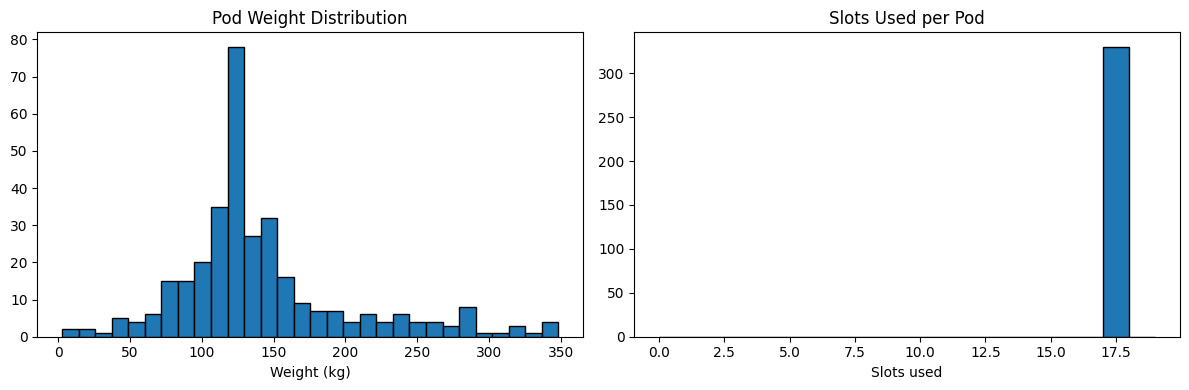

,pod_id,used_slots,total_slots,empty_slots,total_boxes,total_items,total_weight,num_classes
count,330.000000,330.0,330.0,330.0,330.000000,330.000000,330.000000,330.00000
mean,164.500000,17.0,17.0,0.0,85.975758,323.821212,141.769409,1.60000
std,95.407023,0.0,0.0,0.0,26.794150,222.430676,61.361757,0.57082
min,0.000000,17.0,17.0,0.0,19.000000,27.000000,2.680000,1.00000
25%,82.250000,17.0,17.0,0.0,81.250000,184.250000,109.967500,1.00000
50%,164.500000,17.0,17.0,0.0,84.000000,247.000000,125.510000,2.00000
75%,246.750000,17.0,17.0,0.0,94.000000,360.000000,155.026000,2.00000
max,329.000000,17.0,17.0,0.0,278.000000,1272.000000,348.360000,3.00000


In [23]:
import matplotlib.pyplot as plt

pod_df = pd.read_csv(REPO / "assignment" / "pod_summary.csv")
print(f"Total pods: {len(pod_df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pod_df["total_weight"], bins=30, edgecolor="black")
axes[0].set_title("Pod Weight Distribution"); axes[0].set_xlabel("Weight (kg)")
axes[1].hist(pod_df["used_slots"], bins=range(0, 20), edgecolor="black")
axes[1].set_title("Slots Used per Pod"); axes[1].set_xlabel("Slots used")
plt.tight_layout(); plt.show()

pod_df.describe()

In [24]:
# Assignment by cluster
if "cluster" in sku_df.columns:
    cs = sku_df.groupby("cluster").agg(
        n_skus=("item_code", "count"),
        boxes_assigned=("total_boxes_assigned", "sum"),
        skus_assigned=("total_boxes_assigned", lambda x: (x > 0).sum()),
    )
    cs["pct_skus_assigned"] = (cs["skus_assigned"] / cs["n_skus"] * 100).round(1)
    print(cs)

         n_skus  boxes_assigned  skus_assigned  pct_skus_assigned
cluster                                                          
0           388          1011.0            330               85.1
1           111          1454.0             87               78.4
2           472          4395.0            344               72.9
3            29         21512.0             28               96.6


In [25]:
import os

unassigned_path = REPO / "assignment" / "unassigned_skus.csv"
if unassigned_path.exists() and os.path.getsize(unassigned_path) > 1:
    unassigned_df = pd.read_csv(unassigned_path)
    print(f"Unassigned SKUs: {len(unassigned_df)}")
    unassigned_df.head(20)
else:
    print("No unassigned_skus.csv — all SKUs fully assigned!")

No unassigned_skus.csv — all SKUs fully assigned!


---
## Phase 4 — Convert to Simulation Format

Translates the FFD assignment into the NetLogo simulator's `items.csv` and `pods.csv` formats.

In [26]:
import sys

# Clear cached modules to ensure latest code is loaded
for mod in list(sys.modules.keys()):
    if 'convert_to_sim' in mod:
        del sys.modules[mod]

import convert_to_sim
from convert_to_sim import generate_items_csv, convert_detail_to_pods_csv

netlogo_dir = REPO / "netlogo"

items_sim = generate_items_csv(
    sku_sample_path = REPO / "sku_sample.csv",
    items_dict_path = REPO / "sku_sample.csv",
    output_path     = netlogo_dir / "items.csv",
)

pods_sim = convert_detail_to_pods_csv(
    detail_df      = detail_df,
    items_df       = items_sim,
    output_path    = netlogo_dir / "pods.csv",
    pods_dict_path = netlogo_dir / "pods_dictionary.csv",
    rop_path       = REPO / "sku_rop.csv",
)

print(f"items.csv : {len(items_sim)} items")
print(f"pods.csv  : {len(pods_sim)} slot assignments across {pods_sim['pod_id'].nunique()} pods")
if 'rop_per_pod' in pods_sim.columns:
    print(f"rop_per_pod — min: {pods_sim['rop_per_pod'].min()}, max: {pods_sim['rop_per_pod'].max()}, zeros: {(pods_sim['rop_per_pod'] == 0).sum()}")

  items.csv: 1000 items written to /Users/salsahmd/Downloads/rmfs-replenishment/netlogo/items.csv
  pods.csv: 5610 slots across 330 pods written to /Users/salsahmd/Downloads/rmfs-replenishment/netlogo/pods.csv
items.csv : 1000 items
pods.csv  : 5610 slot assignments across 330 pods


---
## Phase 5 — Run Simulation (Baseline)

Output: `results_baseline/summary.csv`, `tick_metrics.csv`, `orders.csv`.

> Set `MAX_TICKS` lower (e.g. 500) for a quick smoke-test.

In [27]:
import subprocess

MAX_TICKS = 1000

proc = subprocess.run(
    [sys.executable, str(REPO / "pipeline" / "run_baseline.py"),
     "--max-ticks", str(MAX_TICKS)],
    text=True,
    capture_output=True,
)
print(proc.stderr)
if proc.stdout:
    print(proc.stdout)
if proc.returncode != 0:
    print(f"[ERROR] process exited with code {proc.returncode}")


  RMFS Baseline Pipeline (Rika's baseline)
  Max ticks: 1000
Traceback (most recent call last):
  File "/Users/salsahmd/Downloads/rmfs-replenishment/pipeline/run_baseline.py", line 277, in <module>
    main()
    ~~~~^^
  File "/Users/salsahmd/Downloads/rmfs-replenishment/pipeline/run_baseline.py", line 261, in main
    run_data = run_simulation(args.max_ticks)
  File "/Users/salsahmd/Downloads/rmfs-replenishment/pipeline/run_baseline.py", line 73, in run_simulation
    from netlogo import setup as sim_setup, tick as sim_tick
  File "/Users/salsahmd/Downloads/rmfs-replenishment/netlogo/netlogo.py", line 10, in <module>
    import networkx as nx
ModuleNotFoundError: No module named 'networkx'

[ERROR] process exited with code 1


---
## Phase 6 — Results & Analysis

In [28]:
results_dir = REPO / "results_baseline"

summary_path = results_dir / "summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    print(summary.T.to_string())
else:
    print("No summary.csv yet — run Phase 5 first.")

                                   0
max_ticks                         10
pipeline                    baseline
ticks                             10
orders_finished                 3733
total_energy              190.712621
stop_and_go                        0
total_turning                      8
peak_job_queue                    32
avg_job_queue                   27.5
orders_generated                 260
order_throughput             14.3577
total_picks                        0
total_replenishments               0
replenishment_pick_ratio         0.0
total_units_picked                 0
pod_visits                         0
pod_utilization                  0.0


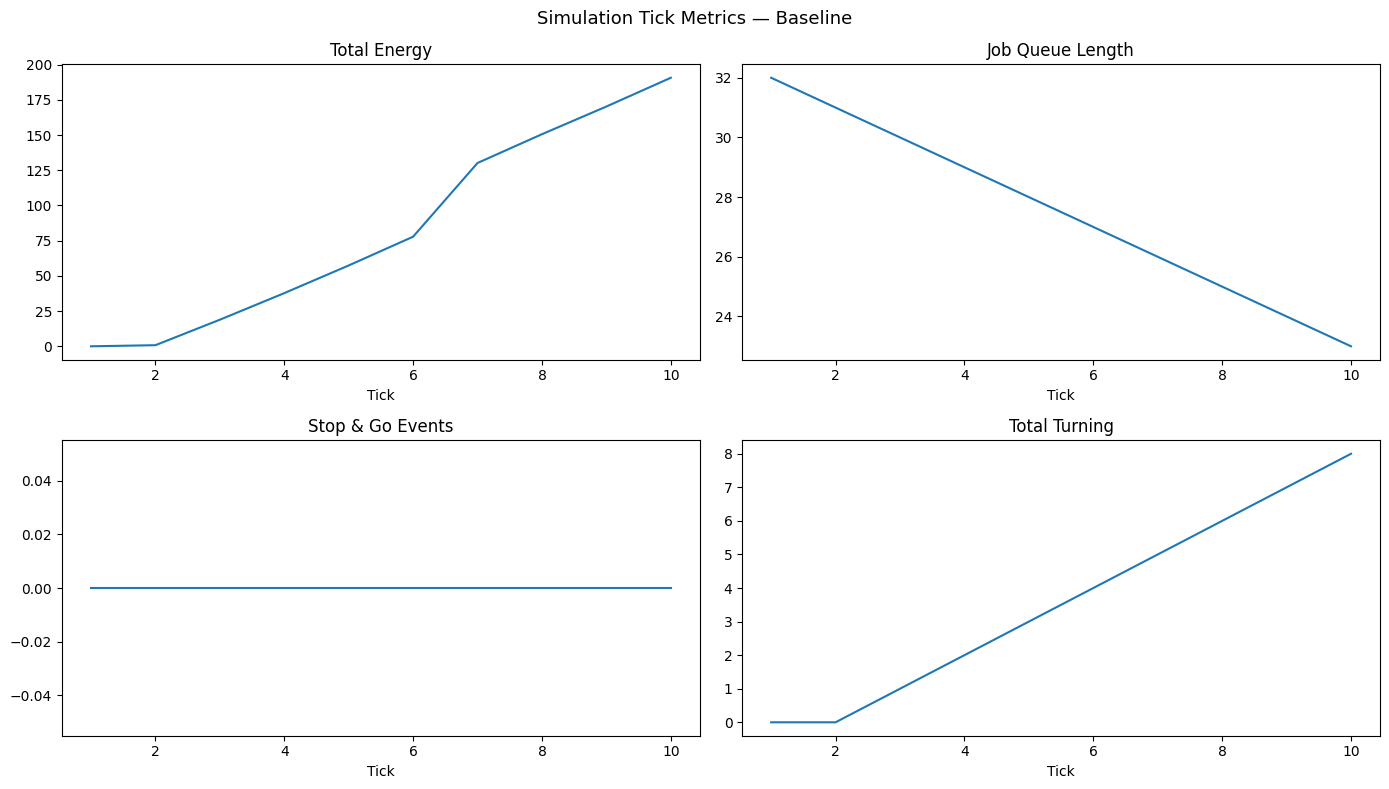

In [29]:
tick_path = results_dir / "tick_metrics.csv"
if tick_path.exists():
    tick_df = pd.read_csv(tick_path)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, (col, title) in zip(axes.flat, [
        ("total_energy",  "Total Energy"),
        ("job_queue_len", "Job Queue Length"),
        ("stop_and_go",   "Stop & Go Events"),
        ("total_turning", "Total Turning"),
    ]):
        if col in tick_df.columns:
            ax.plot(tick_df["tick"], tick_df[col])
            ax.set_title(title); ax.set_xlabel("Tick")
    plt.suptitle("Simulation Tick Metrics — Baseline", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("No tick_metrics.csv yet — run Phase 5 first.")

count     3733.000000
mean       887.988749
std       2082.770661
min         34.000000
25%        142.000000
50%        374.000000
75%        848.000000
max      34690.000000
Name: cycle_time, dtype: float64


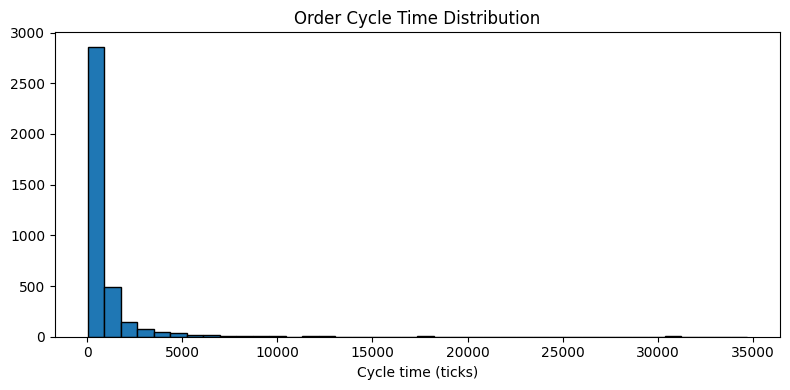

In [30]:
orders_path = results_dir / "orders.csv"
if orders_path.exists():
    orders_df = pd.read_csv(orders_path)
    if "order_complete_time" in orders_df.columns and "process_start_time" in orders_df.columns:
        orders_df["cycle_time"] = orders_df["order_complete_time"] - orders_df["process_start_time"]
        print(orders_df["cycle_time"].describe())
        plt.figure(figsize=(8, 4))
        plt.hist(orders_df["cycle_time"].dropna(), bins=40, edgecolor="black")
        plt.title("Order Cycle Time Distribution"); plt.xlabel("Cycle time (ticks)")
        plt.tight_layout(); plt.show()
    else:
        print(orders_df.head())
else:
    print("No orders.csv yet — run Phase 5 first.")